# CNN com transformada Wavelet no Pipeline

## Wavelet Biorthogonal 1.3

Agora vamos variar a wavelet mãe usada para verificar como irá se comportar o modelo.

A wavelet mãe escolhida foi a Biorthogonal, pois é uma função muito citada em artigos que utilizam a wavelet como realce de características, ou seja, espera-se que tenhamos um resultado melhor de acurácia.

A função wavelet Biorthogonal tem esse formato:

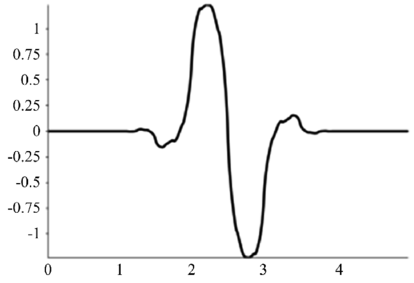

Percebe-se que é uma função com bordas de transição mais suaves, o que ao contrário da Haar (que é muito "quadrada"), as Biorthogonal possuem funções de reconstrução e decomposição diferentes. Isso permite que elas capturem texturas suaves e bordas de nódulos de forma muito mais precisa.

## Implementação da Camada Wavelet Biorthogonal 1.3

Abaixo código da camada implementada, sendo a Bior 1.3, da qual possue filtros de decomposição para extrair as 4 sub-bandas (Aproximação, Horizontal, Vertical e Diagonal).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BiorWaveletLayer(nn.Module):
    def __init__(self):
        super(BiorWaveletLayer, self).__init__()

        # Coeficientes do filtro de decomposição Bior 1.3
        # Estes valores são padrões matemáticos para extrair frequências específicas
        low_pass = torch.tensor([-0.0884, 0.0884, 0.7071, 0.7071, 0.0884, -0.0884])
        high_pass = torch.tensor([0.0884, -0.0884, 0.7071, -0.7071, 0.0884, 0.0884])

        # Criando os 4 filtros (LL, LH, HL, HH) via produto externo
        ll = torch.outer(low_pass, low_pass)   # Aproximação (Média suave)
        lh = torch.outer(high_pass, low_pass)  # Detalhe Horizontal
        hl = torch.outer(low_pass, high_pass)  # Detalhe Vertical
        hh = torch.outer(high_pass, high_pass) # Detalhe Diagonal

        # Stack dos filtros: (out_channels=4, in_channels=1, H=6, W=6)
        filtros = torch.stack([ll, lh, hl, hh], dim=0).unsqueeze(1)
        
        # Registramos como buffer para que esses filtros não sejam alterado pelo otimizador (fixo)
        self.register_buffer("weight", filtros)
        
        # Padding necessário para filtros de tamanho 6 e stride 2
        self.padding = 2 

    def forward(self, x):
        # x deve ter formato (Batch, 1, H, W)
        # stride=2 - filtro pula de 2 em 2 pixels e faz com que a imagem de saída tenha metade do tamanho da entrada
        return F.conv2d(x, self.weight, stride=2, padding=self.padding)

Vale ressaltar algumas característivas das Biorthogonais:

- Simetria: elas são simétricas, o que contribui para não haver um "deslocamento" de artefatos na imagem.
- Suave: enquanto a Haar é mais agressiva na transição (por ser um degrau), a Bior tem bordas mais suaves.

Ao passar uma imagem de mamografia de 256×256 por essa camada, a saída terá o formato [Batch, 4, 130, 130] (o tamanho exato depende do padding).

- O canal 0 será a imagem "limpa".
- Os canais 1, 2 e 3 serão mapas de texturas onde o brilho indica a presença de bordas ou microcalcificações.


Resumo do Fluxo de Dados passando pela Camada Wavelet:

- Entrada: Imagem original (ex: 256×256).
- Processamento: 4 filtros matemáticos (Bior 1.3) deslizam sobre ela.
- Saída: 4 imagens menores (ex: 130×130), isso devido ao parâmetr0 "stride=2", caso desejamos que seja apenas um filtro de realce sem redução da imagem basta deixar o "stride=1". Cada uma foca em um aspecto: a forma geral, as bordas horizontais, as verticais e as texturas finas.

## Classificando as imagnes do Dataset mini-mias

In [2]:
import os
import random
import shutil
from PyPDF2 import PdfReader

pasta_imagens = "dataset-mias/"

com_nodulo = []
sem_nodulo = []

# LER PDF
reader = PdfReader("dataset-mias/00README.pdf")
linhas = []

for pagina in reader.pages:
    texto = pagina.extract_text()
    linhas.extend(texto.split("\n"))

# PROCESSAR
for linha in linhas:
    if "mdb" in linha:
        partes = linha.split()
        nome = partes[0] + ".pgm"
        
        if "NORM" in linha:
            sem_nodulo.append(nome)
        else:
            com_nodulo.append(nome)

# DIVIDIR
def dividir(lista, pasta_train, pasta_test):
    random.shuffle(lista)
    corte = int(0.7 * len(lista))
    
    for nome in lista[:corte]:
        origem = os.path.join(pasta_imagens, nome)
        destino = os.path.join(pasta_train, nome)
        if os.path.exists(origem):
            shutil.copy(origem, destino)
    
    for nome in lista[corte:]:
        origem = os.path.join(pasta_imagens, nome)
        destino = os.path.join(pasta_test, nome)
        if os.path.exists(origem):
            shutil.copy(origem, destino)

# PASTAS
os.makedirs("dataset/train/com_nodulo", exist_ok=True)
os.makedirs("dataset/train/sem_nodulo", exist_ok=True)
os.makedirs("dataset/test/com_nodulo", exist_ok=True)
os.makedirs("dataset/test/sem_nodulo", exist_ok=True)

# EXECUTAR
dividir(com_nodulo, "dataset/train/com_nodulo", "dataset/test/com_nodulo")
dividir(sem_nodulo, "dataset/train/sem_nodulo", "dataset/test/sem_nodulo")

print("Finalizado!")

Finalizado!


## Carregando dataset para CNN aplicando Data Augmentation (aumento de dados)

In [3]:
import cv2
import numpy as np
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from collections import Counter

# 1. Defina a classe do CLAHE
class ApplyCLAHE(object):
    def __init__(self):
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    def __call__(self, img):
        img_np = np.array(img)

        # força grayscale
        if len(img_np.shape) == 3:
            img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

        # normaliza corretamente para uint8
        if img_np.dtype != np.uint8:
            img_np = img_np.astype(np.float32)

            # normaliza entre 0 e 255
            img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
            img_np = (img_np * 255).astype(np.uint8)

        # aplica CLAHE
        img_clahe = self.clahe.apply(img_np)

        return Image.fromarray(img_clahe)

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    ApplyCLAHE(),  
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    ApplyCLAHE(),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(root="dataset/train", transform=train_transform)
test_dataset = datasets.ImageFolder(root="dataset/test", transform=test_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Modelo com 4 convoluções integrando a camada Wavelet e com Data Augmentation

<img src="img/waveletCNN-modelo8.png" width="700" title="Dica de ferramenta">

In [5]:
"""
MODELO COM A WAVELET E 4 CONVOLUÇÕES ("Wavelet -> Conv -> Conv ...")
"""
class WaveletCNN(nn.Module):
    def __init__(self):
        super(WaveletCNN, self).__init__()

        self.wavelet = BiorWaveletLayer()  # saída: 4 canais

        self.features = nn.Sequential(
            nn.Conv2d(4, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.wavelet(x)
        x = self.features(x)
        x = self.classifier(x)
        return x

#### Antes do treino:

Conta quantas amostras existem de cada classe, é importante isso quando temos um dataset desbalanceado.

In [7]:
from collections import Counter

labels_list = [label for _, label in train_dataset.samples]

class_counts_dict = Counter(labels_list)

print("Distribuição das classes:", class_counts_dict)

num_normal = class_counts_dict[0]
num_cancer = class_counts_dict[1]

Distribuição das classes: Counter({1: 143, 0: 80})


## Treinando o modelo

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Modelo
model = WaveletCNN()

# 2. Dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 3. Loss com balanceamento
class_counts = [num_normal, num_cancer]

weights = 1. / torch.tensor(class_counts, dtype=torch.float)
weights = weights / weights.sum()

criterion = nn.CrossEntropyLoss(weight=weights.to(device))

# 4. Otimizador
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# 5. Scheduler 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)


epochs = 50

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    corretos_treino = 0
    total_treino = 0
    
    for imagens, labels in train_loader:
        imagens, labels = imagens.to(device), labels.to(device)
        
        outputs = model(imagens)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_treino += labels.size(0)
        corretos_treino += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * corretos_treino / total_treino
    
    print(f"Época [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} - Acc Treino: {epoch_acc:.2f}%")

    scheduler.step(epoch_loss)

    # Validação
    if (epoch + 1) % 5 == 0:
        model.eval()
        corretos_teste = 0
        total_teste = 0

        with torch.no_grad():
            for imgs, lbls in test_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = model(imgs)
                _, pred = torch.max(out, 1)

                total_teste += lbls.size(0)
                corretos_teste += (pred == lbls).sum().item()

        print(f">>> Acurácia de Teste: {100 * corretos_teste / total_teste:.2f}%")

Época [1/50] - Loss: 0.7028 - Acc Treino: 47.98%
Época [2/50] - Loss: 0.7072 - Acc Treino: 49.78%
Época [3/50] - Loss: 0.7090 - Acc Treino: 47.53%
Época [4/50] - Loss: 0.6926 - Acc Treino: 50.67%
Época [5/50] - Loss: 0.6900 - Acc Treino: 53.36%
>>> Acurácia de Teste: 63.92%
Época [6/50] - Loss: 0.6898 - Acc Treino: 56.05%
Época [7/50] - Loss: 0.6833 - Acc Treino: 56.05%
Época [8/50] - Loss: 0.6712 - Acc Treino: 54.71%
Época [9/50] - Loss: 0.6758 - Acc Treino: 59.64%
Época [10/50] - Loss: 0.6911 - Acc Treino: 56.05%
>>> Acurácia de Teste: 51.55%
Época [11/50] - Loss: 0.6816 - Acc Treino: 59.19%
Época [12/50] - Loss: 0.6863 - Acc Treino: 56.95%
Época [13/50] - Loss: 0.6789 - Acc Treino: 52.91%
Época [14/50] - Loss: 0.6719 - Acc Treino: 57.85%
Época [15/50] - Loss: 0.6594 - Acc Treino: 63.68%
>>> Acurácia de Teste: 51.55%
Época [16/50] - Loss: 0.6670 - Acc Treino: 61.88%
Época [17/50] - Loss: 0.6708 - Acc Treino: 63.23%
Época [18/50] - Loss: 0.6690 - Acc Treino: 59.19%
Época [19/50] - Los

## Testando o modelo

In [9]:
model.eval()
corretos = 0
total = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():
    for imagens, labels in test_loader:
        
        imagens, labels = imagens.to(device), labels.to(device)

        outputs = model(imagens)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        corretos += (predicted == labels).sum().item()

print(f"Acurácia: {100 * corretos / total:.2f}%")

Acurácia: 53.61%
